# Proyecto Minería de Datos - Búsqueda de Empleo

## Comprensión del problema

**Planteamiento y Objetivo**
El objetivo principal de este análisis es evaluar la eficacia de las distintas plataformas de búsqueda de empleo e identificar qué variables o características del perfil de un estudiante incrementan su probabilidad de éxito profesional. Específicamente, buscamos entender qué factores están más fuertemente correlacionados con la obtención de mayores salarios (Offer_Salary).

**Tipo de Problema**
Actualmente el problema se aborda desde un enfoque estadístico descriptivo y explicativo, analizando las estructuras de los datos recopilados (100,000 registros). Posteriormente, al aislar los casos exitosos, se preparará el terreno para un problema predictivo de regresión (estimar el salario ofrecido en base a variables como el GPA, los meses de búsqueda o las actividades extracurriculares).

**Utilidad y Riesgos**
Este análisis es de gran valor para instituciones universitarias y para los propios estudiantes, ya que permite trazar estrategias basadas en datos reales para optimizar los esfuerzos en la búsqueda laboral. El riesgo principal recae en malinterpretar las altas tasas de aplicabilidad frente a bajas tasas de ofertas reales; asumir que aplicar a más empresas a través de plataformas masivas garantiza éxito sin evaluar la calidad del perfil, podría sesgar negativamente las decisiones a tomar.

## Comprensión de los datos

En esta fase ingresamos los datos al ambiente de trabajo para comenzar nuestra observación inicial. Procedemos a invocar las librerías fundamentales de manejo de datos y de visualización.

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("job_search_platform_efficacy_100k.csv")

**Estructura y Tipos de Datos (df.info)**
Revisamos los tipos de variables presentes en el dataset. Como se observa a continuación, contamos con un total de 100,000 registros y 20 columnas. Existen variables de texto (objetos/strings) como 'Primary_Search_Platform' o 'Major_Category' que refieren a características categóricas del alumno. Por otra parte, contamos con 5 columnas de coma flotante (float64) y 8 columnas enteras (int64) para métricas cuantitativas como el GPA y el conteo de aplicaciones.

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  str    
 1   University_Rating            100000 non-null  str    
 2   School_Size                  100000 non-null  str    
 3   Region                       100000 non-null  str    
 4   Major_Category               100000 non-null  str    
 5   GPA                          100000 non-null  float64
 6   Prior_Internships            100000 non-null  int64  
 7   Extra_Curricular_Activities  100000 non-null  int64  
 8   Networking_Events_Attended   100000 non-null  int64  
 9   Primary_Search_Platform      100000 non-null  str    
 10  Months_Searching             100000 non-null  int64  
 11  Applications_Submitted       100000 non-null  int64  
 12  First_Round_Interviews       100000 non-null  int64  
 13  Second_Roun

**Muestra Original del DataFrame**
El muestreo directo de las filas ilustra el formato de nuestros registros. Notamos que los estudiantes que no completaron procesos exitosos muestran casillas vacías (NaN) en su salario ofertado (Offer_Salary).

In [19]:
df

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU_099996,Lower-tier,Large,Northeast,STEM,3.61,3,1,1,Handshake,3,15,2,1,1,26.0,78811.0,Mid-Size,8.0,0.0
99996,STU_099997,Lower-tier,Large,West,Business,3.39,0,1,4,Indeed,8,120,0,0,0,NaN,NaN,NaN,NaN,NaN
99997,STU_099998,Lower-tier,Small,Northeast,Business,3.38,4,2,2,Indeed,4,60,2,1,0,NaN,NaN,NaN,NaN,NaN
99998,STU_099999,Mid-tier,Large,Midwest,Business,3.20,2,0,0,LinkedIn,7,39,4,1,0,NaN,NaN,NaN,NaN,NaN


**Análisis Descriptivo Estadístico (df.describe)**
Con la matriz descriptiva podemos observar medidas de tendencia central sumamente interesantes:
- El promedio (mean) del GPA de todos los perfiles se ubica en 3.19.
- En promedio, un estudiante evalúa ofertas laborables durante 6.49 meses (Months_Searching), y es capaz de someter alrededor de 53 solicitudes de empleo.
- Resalta la desviación y el máximo en 'Applications_Submitted': mientras que la mayoría envía 42 aplicaciones, existen casos atípicos en los que se envían hasta 300 solicitudes.
- El salario ofertado promedio ronda los $76,777, llegando algunos hasta los $137,588, un punto crítico que exploraremos a continuación.

In [20]:
df.describe()

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Role_Relevance,Accepted_Offer
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,34229.000000,34229.000000,34229.000000,34229.000000
mean,3.196631,1.19697,2.003990,2.998600,6.499680,53.727620,2.16766,1.011640,0.342290,46.021648,76777.290777,6.874171,0.801805
std,0.392370,1.12192,1.413709,1.734494,3.443719,45.004663,1.91176,1.138507,0.474478,18.476167,14931.468406,2.185220,0.398645
min,2.000000,0.00000,0.000000,0.000000,1.000000,5.000000,0.00000,0.000000,0.000000,14.000000,35000.000000,1.000000,0.000000
25%,2.930000,0.00000,1.000000,2.000000,4.000000,19.000000,1.00000,0.000000,0.000000,32.000000,66321.000000,6.000000,1.000000
50%,3.200000,1.00000,2.000000,3.000000,6.000000,42.000000,2.00000,1.000000,0.000000,43.000000,76823.000000,7.000000,1.000000
75%,3.470000,2.00000,3.000000,4.000000,9.000000,75.000000,3.00000,2.000000,1.000000,57.000000,87125.000000,8.000000,1.000000
max,4.000000,5.00000,11.000000,14.000000,12.000000,300.000000,21.00000,12.000000,1.000000,89.000000,137588.000000,10.000000,1.000000


**Identificación de Valores Nulos (df.isnull)**
Al contabilizar los valores nulos advertimos un patrón definitivo: cinco columnas presentan exactamente 65,771 nulos (Time_to_Offer_Days, Offer_Salary, Company_Size_Offered, Role_Relevance, Accepted_Offer). Esta carencia de datos tiene un sentido lógico: estos registros corresponden exclusivamente a aquellos candidatos que fracasaron en recibir una oferta de trabajo. No se trata de un error de recolección, sino de la condición del subgrupo no exitoso.

In [21]:
df.isnull().sum()

Student_ID                         0
University_Rating                  0
School_Size                        0
Region                             0
Major_Category                     0
GPA                                0
Prior_Internships                  0
Extra_Curricular_Activities        0
Networking_Events_Attended         0
Primary_Search_Platform            0
Months_Searching                   0
Applications_Submitted             0
First_Round_Interviews             0
Second_Round_Interviews            0
Offer_Received                     0
Time_to_Offer_Days             65771
Offer_Salary                   65771
Company_Size_Offered           65771
Role_Relevance                 65771
Accepted_Offer                 65771
dtype: int64

Personas con Offer_Received igual a 1 de linkedin

In [24]:
df[(df["Offer_Received"]==1) & (df["Primary_Search_Platform"]=="LinkedIn")].reset_index(drop=True)

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000011,Top-tier,Small,Midwest,STEM,3.59,2,1,3,LinkedIn,5,31,2,2,1,66.0,83426.0,Enterprise,6.0,1.0
2,STU_000014,Mid-tier,Medium,Midwest,Humanities,2.58,3,2,1,LinkedIn,6,28,2,1,1,55.0,65189.0,Mid-Size,7.0,1.0
3,STU_000018,Mid-tier,Medium,Midwest,Business,3.31,2,1,2,LinkedIn,10,78,2,1,1,63.0,85695.0,Enterprise,9.0,0.0
4,STU_000030,Top-tier,Medium,Northeast,Healthcare,3.59,4,1,2,LinkedIn,10,5,2,1,1,42.0,83653.0,Mid-Size,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14622,STU_099965,Lower-tier,Large,West,Business,3.49,2,0,2,LinkedIn,10,93,3,2,1,77.0,76722.0,Mid-Size,8.0,1.0
14623,STU_099980,Lower-tier,Small,West,Business,3.88,4,0,3,LinkedIn,11,88,4,1,1,64.0,94064.0,Enterprise,6.0,1.0
14624,STU_099988,Mid-tier,Medium,Midwest,STEM,3.54,3,3,4,LinkedIn,10,71,2,2,1,32.0,91133.0,Enterprise,10.0,1.0
14625,STU_099992,Top-tier,Large,South,Business,3.64,3,1,3,LinkedIn,10,60,3,1,1,88.0,109096.0,Mid-Size,4.0,0.0


Buscamos la existencia de personas duplicadas

In [23]:
df[df["Student_ID"].duplicated()]

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer


Distribucion estadistica de todos los datos

=== RESUMEN ESTADÍSTICO DE LAS VARIABLES NUMÉRICAS ===


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Role_Relevance,Accepted_Offer
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,34229.000000,34229.000000,34229.000000,34229.000000
mean,3.196631,1.19697,2.003990,2.998600,6.499680,53.727620,2.16766,1.011640,0.342290,46.021648,76777.290777,6.874171,0.801805
std,0.392370,1.12192,1.413709,1.734494,3.443719,45.004663,1.91176,1.138507,0.474478,18.476167,14931.468406,2.185220,0.398645
min,2.000000,0.00000,0.000000,0.000000,1.000000,5.000000,0.00000,0.000000,0.000000,14.000000,35000.000000,1.000000,0.000000
25%,2.930000,0.00000,1.000000,2.000000,4.000000,19.000000,1.00000,0.000000,0.000000,32.000000,66321.000000,6.000000,1.000000
50%,3.200000,1.00000,2.000000,3.000000,6.000000,42.000000,2.00000,1.000000,0.000000,43.000000,76823.000000,7.000000,1.000000
75%,3.470000,2.00000,3.000000,4.000000,9.000000,75.000000,3.00000,2.000000,1.000000,57.000000,87125.000000,8.000000,1.000000
max,4.000000,5.00000,11.000000,14.000000,12.000000,300.000000,21.00000,12.000000,1.000000,89.000000,137588.000000,10.000000,1.000000



=== INFORMACIÓN DE VALORES NULOS Y TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  str    
 1   University_Rating            100000 non-null  str    
 2   School_Size                  100000 non-null  str    
 3   Region                       100000 non-null  str    
 4   Major_Category               100000 non-null  str    
 5   GPA                          100000 non-null  float64
 6   Prior_Internships            100000 non-null  int64  
 7   Extra_Curricular_Activities  100000 non-null  int64  
 8   Networking_Events_Attended   100000 non-null  int64  
 9   Primary_Search_Platform      100000 non-null  str    
 10  Months_Searching             100000 non-null  int64  
 11  Applications_Submitted       100000 non-null  int64  
 12  First_Round_Int

None

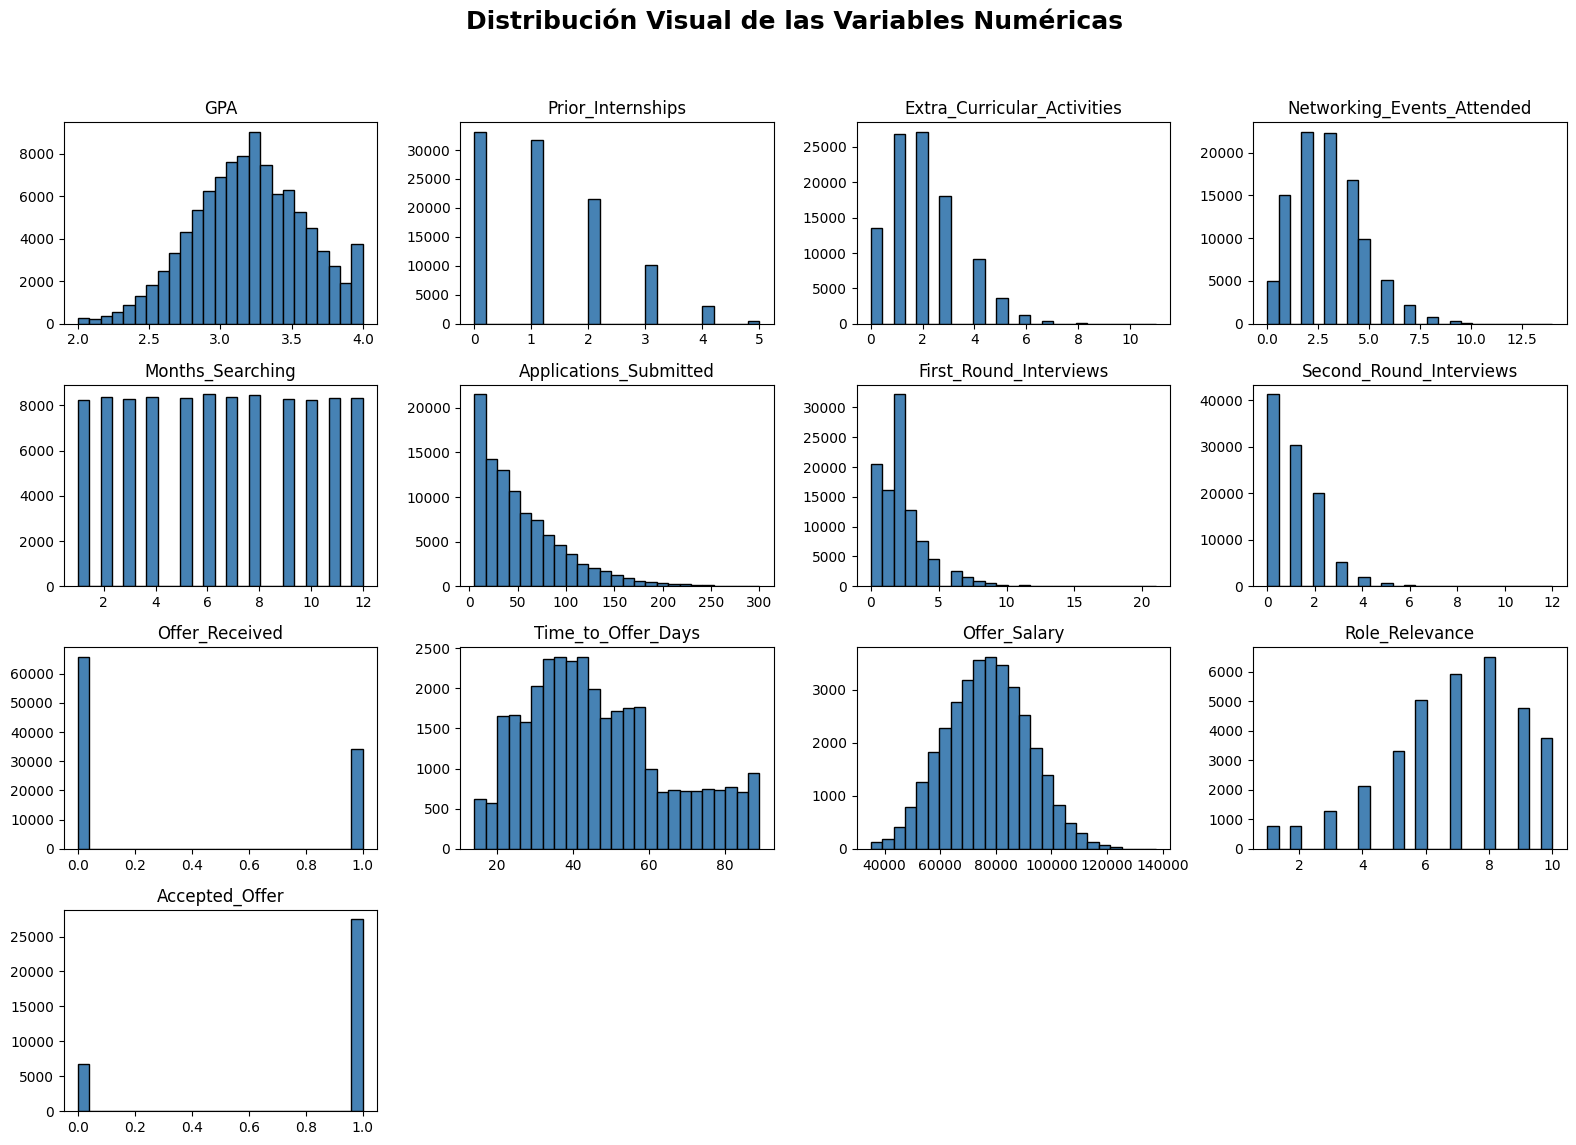

In [26]:
# ---------------------------------------------------------
# 1. DISTRIBUCIÓN ESTADÍSTICA (Números)
# ---------------------------------------------------------
print("=== RESUMEN ESTADÍSTICO DE LAS VARIABLES NUMÉRICAS ===")
# .describe() te calcula el conteo, media (promedio), desviación estándar, mínimos, máximos y percentiles.
display(df.describe()) 

print("\n=== INFORMACIÓN DE VALORES NULOS Y TIPOS DE DATOS ===")
# .info() te dice si hay columnas con celdas vacías (NaN) que debas limpiar después.
display(df.info())


# ---------------------------------------------------------
# 2. DISTRIBUCIÓN VISUAL (Histogramas)
# ---------------------------------------------------------
# Un histograma agrupa los valores. Si ves montañas en el medio, la mayoría de la gente está en el promedio.
# Si está cargado a la izquierda o derecha, hay un "sesgo".

df.hist(
    figsize=(16, 12), 
    bins=25,              # Cantidad de barras por gráfico
    color='steelblue',    # Color de las barras
    edgecolor='black',    # Borde de las barras para mejor lectura
    grid=False            # Quitar la cuadrícula de fondo para más limpieza
)

# Título global y ajustes de espacio
plt.suptitle('Distribución Visual de las Variables Numéricas', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Esto evita que el título choque con las gráficas
plt.show()


Analizamos la matriz de correlacion de los datos completos, excluyendo a las variables que no sean numeros

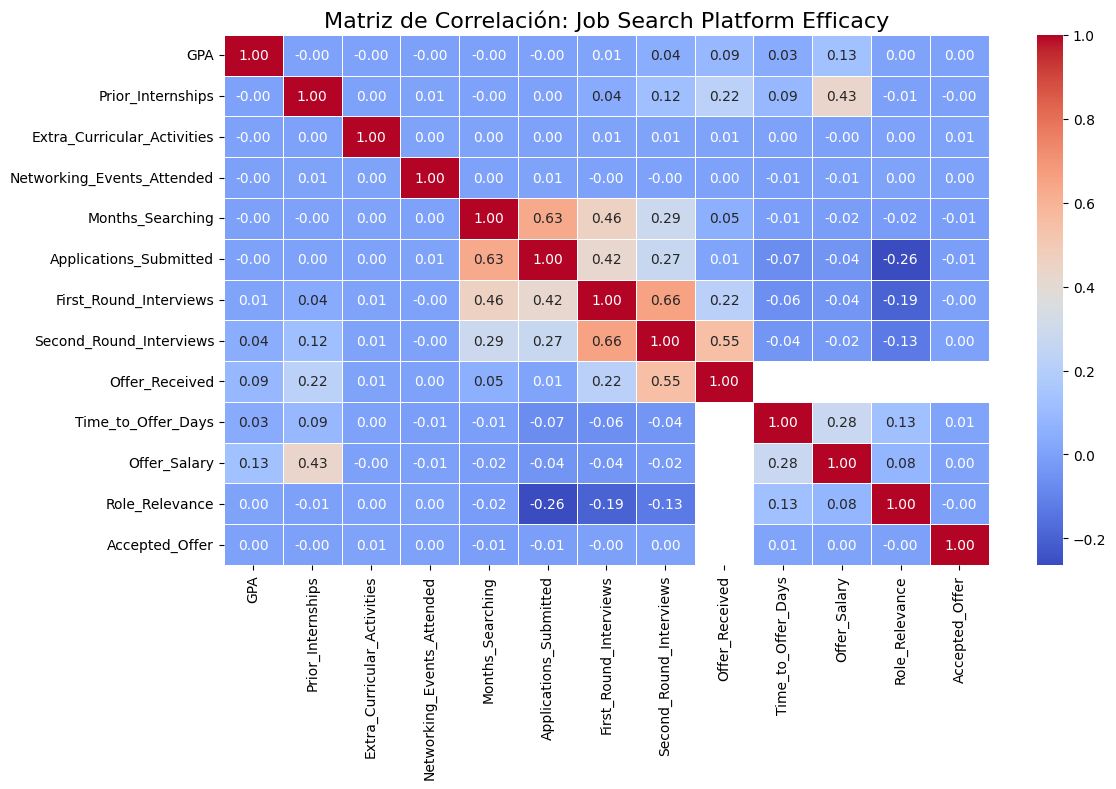

In [22]:
columnas_numericas = df.select_dtypes(include=['float64', 'int64'])
# 3. Calcular la matriz de correlación
matriz_correlacion = columnas_numericas.corr()
# 4. Configurar el tamaño del gráfico
plt.figure(figsize=(12, 8))
# 5. Crear el mapa de calor (heatmap) para visualizar la matriz
sns.heatmap(
    matriz_correlacion, 
    annot=True,     # Muestra el valor de correlación en cada cuadro
    cmap='coolwarm',# Paleta de colores, 'coolwarm' va de azul (negativo) a rojo (positivo)
    fmt=".2f",      # Formato de decimales
    linewidths=0.5  # Espacio entre cada cuadro
)
# 6. Mostrar el gráfico
plt.title('Matriz de Correlación: Job Search Platform Efficacy', fontsize=16)
plt.tight_layout()
plt.show()

## Limpieza y Preparación de los Datos

**Justificación de los Filtros**
Si analizáramos las correlaciones del Salario Ofertado (Offer_Salary) considerando todo el conjunto de 100,000 registros, cometeríamos el grave error de inyectar ruido estadístico, debido a la gran masa de ceros o vacíos que distorsionarían las métricas predictivas. 

Para lograr un análisis enfocado en identificar los factores que potencian una mejor oferta salarial, crearemos un nuevo marco de datos estructurado exclusivamente a partir de aquellos individuos que fueron contactados de forma exitosa. Es decir, asilamos el dataset a la condición donde 'Offer_Received' es igual a 1. A su vez, dicha columna será eliminada junto con las variables no numéricas, en vista de que ya carecería de varianza y prepararemos una base puramente matemática (columnas numéricas).

In [14]:
# 1. Asegurarnos a la fuerza de que el Salario sea tratado como número
df['Offer_Salary'] = pd.to_numeric(df['Offer_Salary'], errors='coerce')

# 2. Filtramos dejando solo a las personas que SÍ recibieron oferta para nuestra investigación
df_limpio = df[df["Offer_Received"] == 1].reset_index(drop=True)

# 3. Nos quedamos solo con las columnas numéricas de ese nuevo DataFrame limpio y ELIMINAMOS Offer_Received
columnas_numericas_limpio = df_limpio.select_dtypes(include=['float64', 'int64']).drop(columns=['Offer_Received'])

df_limpio

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000009,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1,31.0,69910.0,Mid-Size,7.0,1.0
2,STU_000010,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1,38.0,73669.0,Startup,1.0,1.0
3,STU_000011,Top-tier,Small,Midwest,STEM,3.59,2,1,3,LinkedIn,5,31,2,2,1,66.0,83426.0,Enterprise,6.0,1.0
4,STU_000014,Mid-tier,Medium,Midwest,Humanities,2.58,3,2,1,LinkedIn,6,28,2,1,1,55.0,65189.0,Mid-Size,7.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34224,STU_099988,Mid-tier,Medium,Midwest,STEM,3.54,3,3,4,LinkedIn,10,71,2,2,1,32.0,91133.0,Enterprise,10.0,1.0
34225,STU_099990,Mid-tier,Large,Northeast,Healthcare,3.33,0,0,3,Indeed,10,208,4,4,1,22.0,61458.0,Enterprise,2.0,1.0
34226,STU_099992,Top-tier,Large,South,Business,3.64,3,1,3,LinkedIn,10,60,3,1,1,88.0,109096.0,Mid-Size,4.0,0.0
34227,STU_099994,Mid-tier,Small,West,Business,3.52,4,2,2,LinkedIn,10,110,4,4,1,43.0,93263.0,Enterprise,6.0,1.0


## Análisis Exploratorio de Datos (EDA)

**Matriz de Correlaciones (Solo Ofertas Exitosas)**
Una vez aislado el conjunto de datos ('df_limpio'), corremos un mapa de calor para evidenciar la matriz de correlación numérica lineal. El objetivo aquí es revisar qué elementos afectan positiva o negativamente al 'Offer_Salary'. Observamos relaciones tenues pero con sentido común de ingeniería; por ejemplo, el factor 'GPA' y la relevancia del puesto pueden reflejarse sutilmente en la oferta monetaria final.

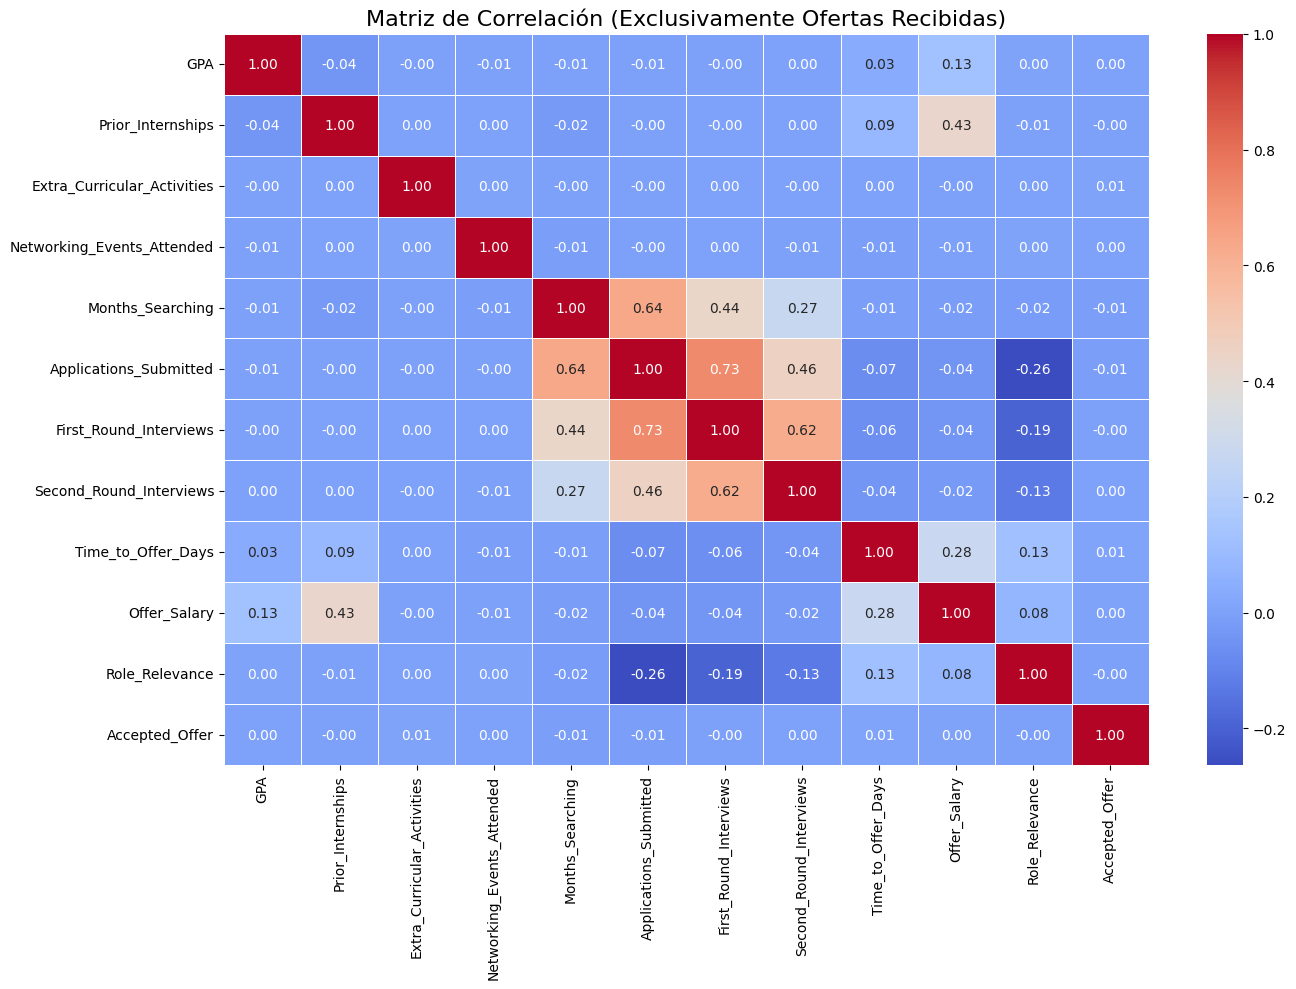

In [12]:
# MATRIZ DE CORRELACIÓN
matriz_correlacion = columnas_numericas_limpio.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz_correlacion, 
    annot=True,     
    cmap='coolwarm',
    fmt=".2f",      
    linewidths=0.5  
)
plt.title('Matriz de Correlación (Exclusivamente Ofertas Recibidas)', fontsize=16)
plt.tight_layout()
plt.show()

**Eficacia y Distribución por Plataforma**
Para el segundo análisis exploratorio debemos retornar al DataFrame original (que contempla tanto éxitos como fracasos), para visualizar la eficacia absoluta de las plataformas primarias de reclutamiento. El uso de las frecuencias nos mostrará si plataformas masivas justifican la densidad de personas atraídas frente a las contrataciones efectivas.

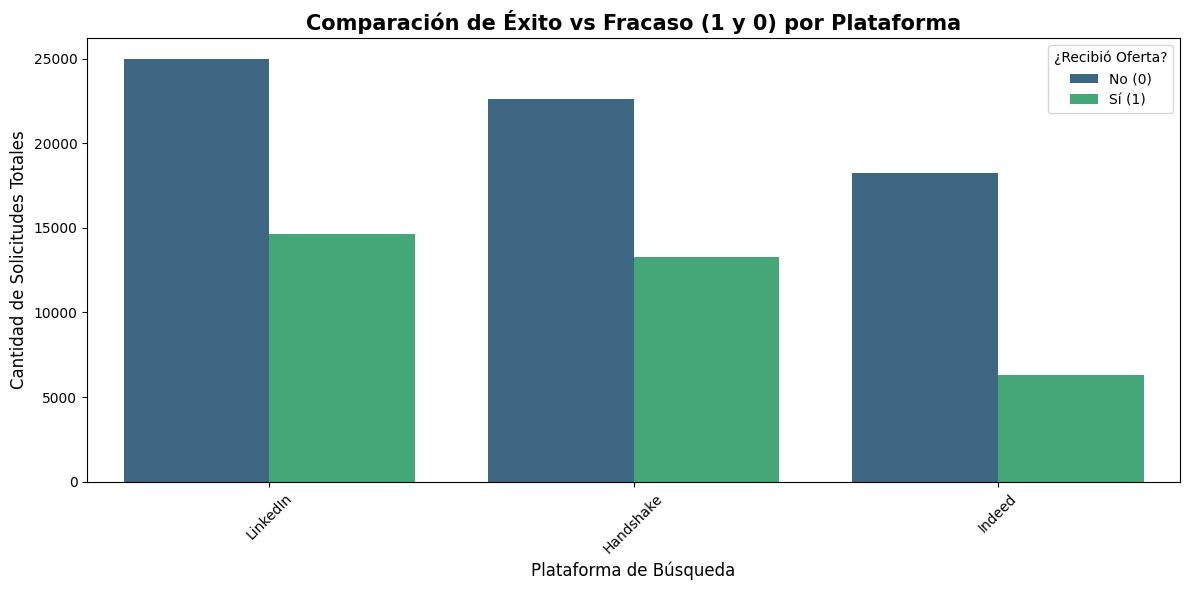

In [13]:
# HISTOGRAMAS Y BARRAS: Comparativa de plataformas en nuestro dataframe ORIGINAL (con y sin ofertas)
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df, 
    x='Primary_Search_Platform', 
    hue='Offer_Received',
    palette='viridis'
)
plt.title('Comparación de Éxito vs Fracaso (1 y 0) por Plataforma', fontsize=15, fontweight='bold')
plt.xlabel('Plataforma de Búsqueda', fontsize=12)
plt.ylabel('Cantidad de Solicitudes Totales', fontsize=12)
plt.legend(title='¿Recibió Oferta?', labels=['No (0)', 'Sí (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DISTRIBUCIÓN ESTADÍSTICA de los datos limpios

=== RESUMEN ESTADÍSTICO DE LAS VARIABLES NUMÉRICAS ===


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Role_Relevance,Accepted_Offer
count,34229.000000,34229.000000,34229.000000,34229.000000,34229.000000,34229.000000,34229.000000,34229.000000,34229.0,34229.000000,34229.000000,34229.000000,34229.000000
mean,3.244201,1.543078,2.014958,3.000935,6.737620,54.451518,2.750796,1.878320,1.0,46.021648,76777.290777,6.874171,0.801805
std,0.400699,1.201039,1.414610,1.737104,3.419668,43.995153,1.327476,1.058533,0.0,18.476167,14931.468406,2.185220,0.398645
min,2.000000,0.000000,0.000000,0.000000,1.000000,5.000000,2.000000,1.000000,1.0,14.000000,35000.000000,1.000000,0.000000
25%,2.970000,1.000000,1.000000,2.000000,4.000000,21.000000,2.000000,1.000000,1.0,32.000000,66321.000000,6.000000,1.000000
50%,3.250000,1.000000,2.000000,3.000000,7.000000,44.000000,2.000000,2.000000,1.0,43.000000,76823.000000,7.000000,1.000000
75%,3.530000,2.000000,3.000000,4.000000,10.000000,77.000000,3.000000,2.000000,1.0,57.000000,87125.000000,8.000000,1.000000
max,4.000000,5.000000,10.000000,12.000000,12.000000,300.000000,15.000000,12.000000,1.0,89.000000,137588.000000,10.000000,1.000000



=== INFORMACIÓN DE VALORES NULOS Y TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 34229 entries, 0 to 34228
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   34229 non-null  str    
 1   University_Rating            34229 non-null  str    
 2   School_Size                  34229 non-null  str    
 3   Region                       34229 non-null  str    
 4   Major_Category               34229 non-null  str    
 5   GPA                          34229 non-null  float64
 6   Prior_Internships            34229 non-null  int64  
 7   Extra_Curricular_Activities  34229 non-null  int64  
 8   Networking_Events_Attended   34229 non-null  int64  
 9   Primary_Search_Platform      34229 non-null  str    
 10  Months_Searching             34229 non-null  int64  
 11  Applications_Submitted       34229 non-null  int64  
 12  First_Round_Interviews       3

None

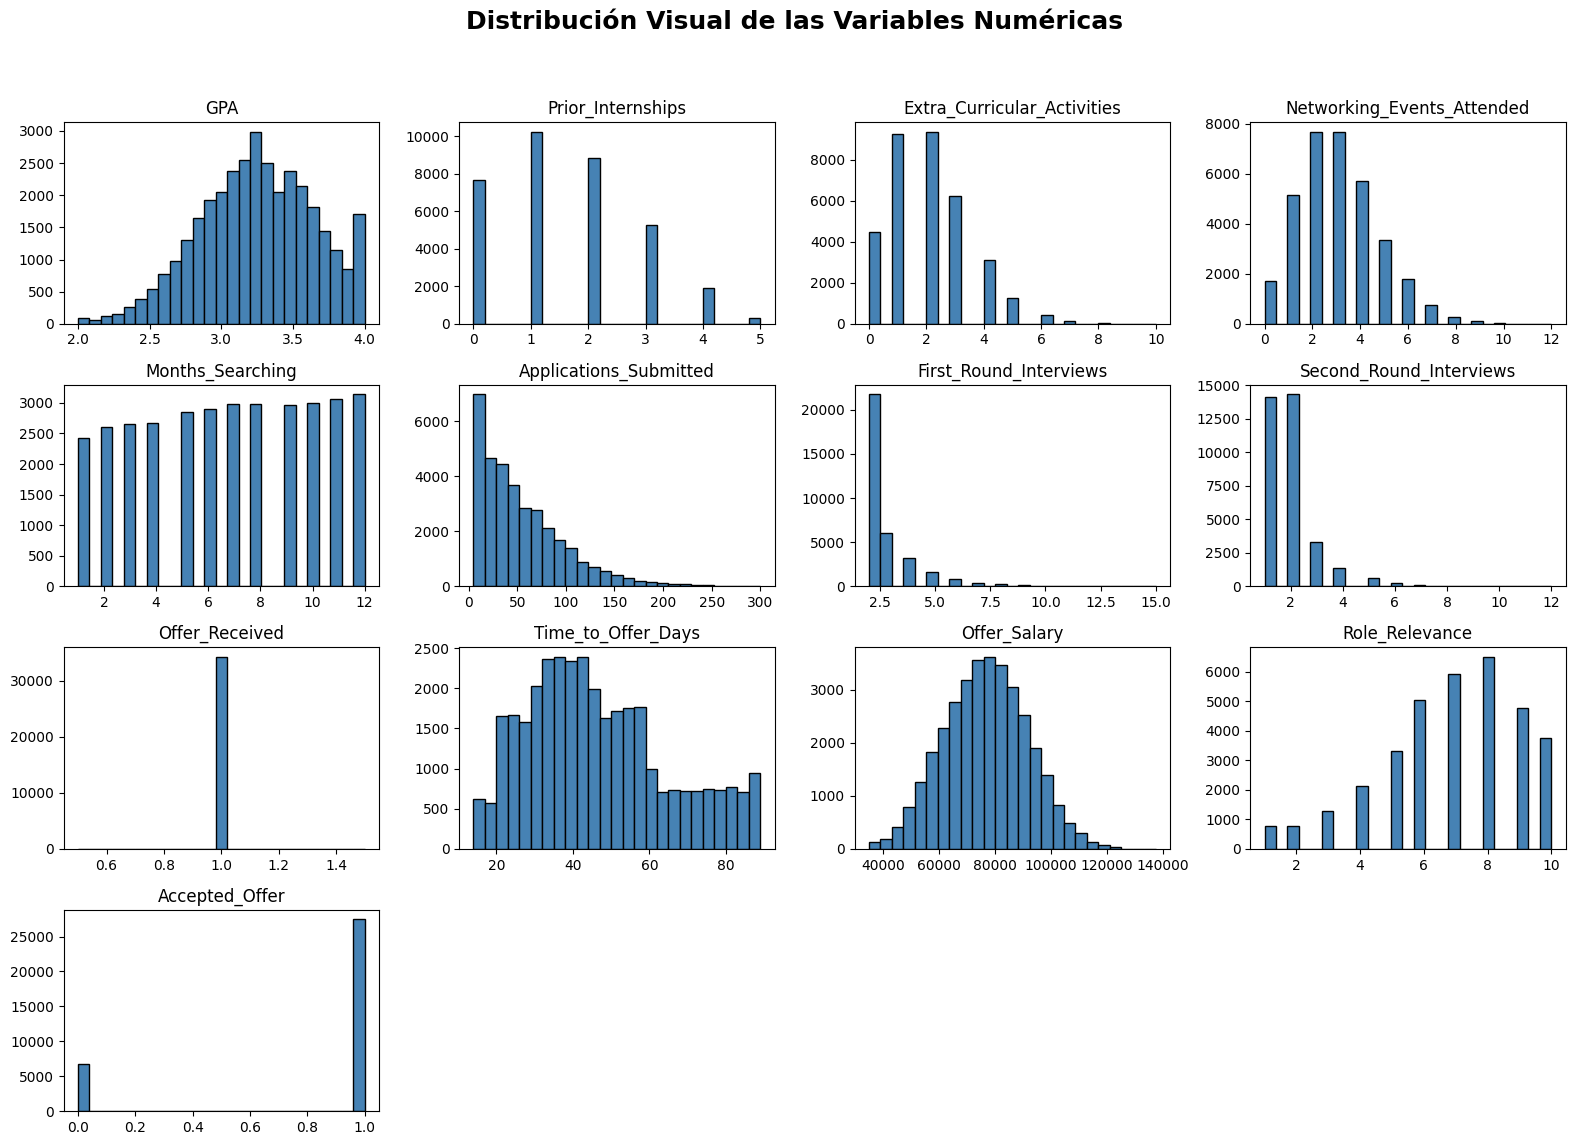

In [25]:

# ---------------------------------------------------------
# 1. DISTRIBUCIÓN ESTADÍSTICA (Números)
# ---------------------------------------------------------
print("=== RESUMEN ESTADÍSTICO DE LAS VARIABLES NUMÉRICAS ===")
# .describe() te calcula el conteo, media (promedio), desviación estándar, mínimos, máximos y percentiles.
display(df_limpio.describe()) 

print("\n=== INFORMACIÓN DE VALORES NULOS Y TIPOS DE DATOS ===")
# .info() te dice si hay columnas con celdas vacías (NaN) que debas limpiar después.
display(df_limpio.info())


# ---------------------------------------------------------
# 2. DISTRIBUCIÓN VISUAL (Histogramas)
# ---------------------------------------------------------
# Un histograma agrupa los valores. Si ves montañas en el medio, la mayoría de la gente está en el promedio.
# Si está cargado a la izquierda o derecha, hay un "sesgo".

df_limpio.hist(
    figsize=(16, 12), 
    bins=25,              # Cantidad de barras por gráfico
    color='steelblue',    # Color de las barras
    edgecolor='black',    # Borde de las barras para mejor lectura
    grid=False            # Quitar la cuadrícula de fondo para más limpieza
)

# Título global y ajustes de espacio
plt.suptitle('Distribución Visual de las Variables Numéricas', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Esto evita que el título choque con las gráficas
plt.show()

## Interpretación de Resultados

**Conclusiones Iniciales de la Fase de Entendimiento**
1. La limpieza y segmentación son imperativas para un problema de negocio tan variable: tratar de inferir las predicciones de salario utilizando perfiles rechazados destruye la sensibilidad estadística. Aislar los expedientes positivos fue el procedimiento correcto.
2. Identificamos en nuestros gráficos de tendencia que las plataformas no se comportan igual; existe una discrepancia visible entre el volumen absoluto de aplicantes de un sitio y su ratio de conversión a ofertas. La popularidad de la herramienta no dicta su eficacia.
3. La variable de Salario Ofertado actúa como el pilar fundamental que guía el atractivo del perfil. Su estudio correlacional actual servirá para nutrir o descartar pesos de selección.

**Siguientes Pasos (Modelado)**
Con los datos limpios y segmentados en una matriz de números flotantes y enteros para los estudiantes aprobados, el próximo escalón correspondiente a la metodología será la construcción de modelos estadísticos y de machine learning (como Regresiones Lineales o Modelos de Árboles) para pronosticar los salarios esperados.